# Phase 5: Publication-Quality Insights

Polished charts and summary tables suitable for README / portfolio use.

Focuses on the most striking findings from Phase 4 with clean, self-explanatory visuals.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

import sys
sys.path.insert(0, str(Path("..").resolve()))

PROCESSED_DIR = Path("..") / "data" / "processed"

# Publication style
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

BLUE   = "#2563EB"
RED    = "#DC2626"
GRAY   = "#6B7280"
YELLOW = "#D97706"

In [2]:
# Load pre-computed outputs from Phase 4
game_agg = pd.read_csv(PROCESSED_DIR / "game_sentiment_agg.csv")
joined   = pd.read_csv(PROCESSED_DIR / "sentiment_game_joined.csv")
scores   = pd.read_csv(PROCESSED_DIR / "sentiment_scores.csv")

print(f"Game aggregates: {len(game_agg)} games")
print(f"Joined turns:    {len(joined):,} turns")
print(f"All scored turns: {len(scores):,} turns")
game_agg.head(3)

Game aggregates: 141 games
Joined turns:    10,881 turns
All scored turns: 23,166 turns


,game_id,date,event_name,series_id,game_num,home_team,away_team,home_win,point_diff,is_elimination_game,next_point_diff,home_series_wins,away_series_wins,mean_sentiment,pct_positive,pct_negative,n_turns
0,41200301,2013-05-22,NBA ECF: PACERS v HEAT,"('IND', 'MIA')_2012",1,MIA,IND,1,1.0,0,-4.0,1,0,0.126137,0.291667,0.166667,48
1,41200302,2013-05-24,NBA ECF: PACERS v HEAT,"('IND', 'MIA')_2012",2,MIA,IND,0,-4.0,0,-18.0,1,1,0.221557,0.428571,0.214286,56
2,41200303,2013-05-26,NBA ECF: PACERS v HEAT,"('IND', 'MIA')_2012",3,IND,MIA,0,-18.0,0,7.0,1,2,0.205530,0.393939,0.212121,33


## Figure 1: Pipeline Overview - Sentiment Distribution

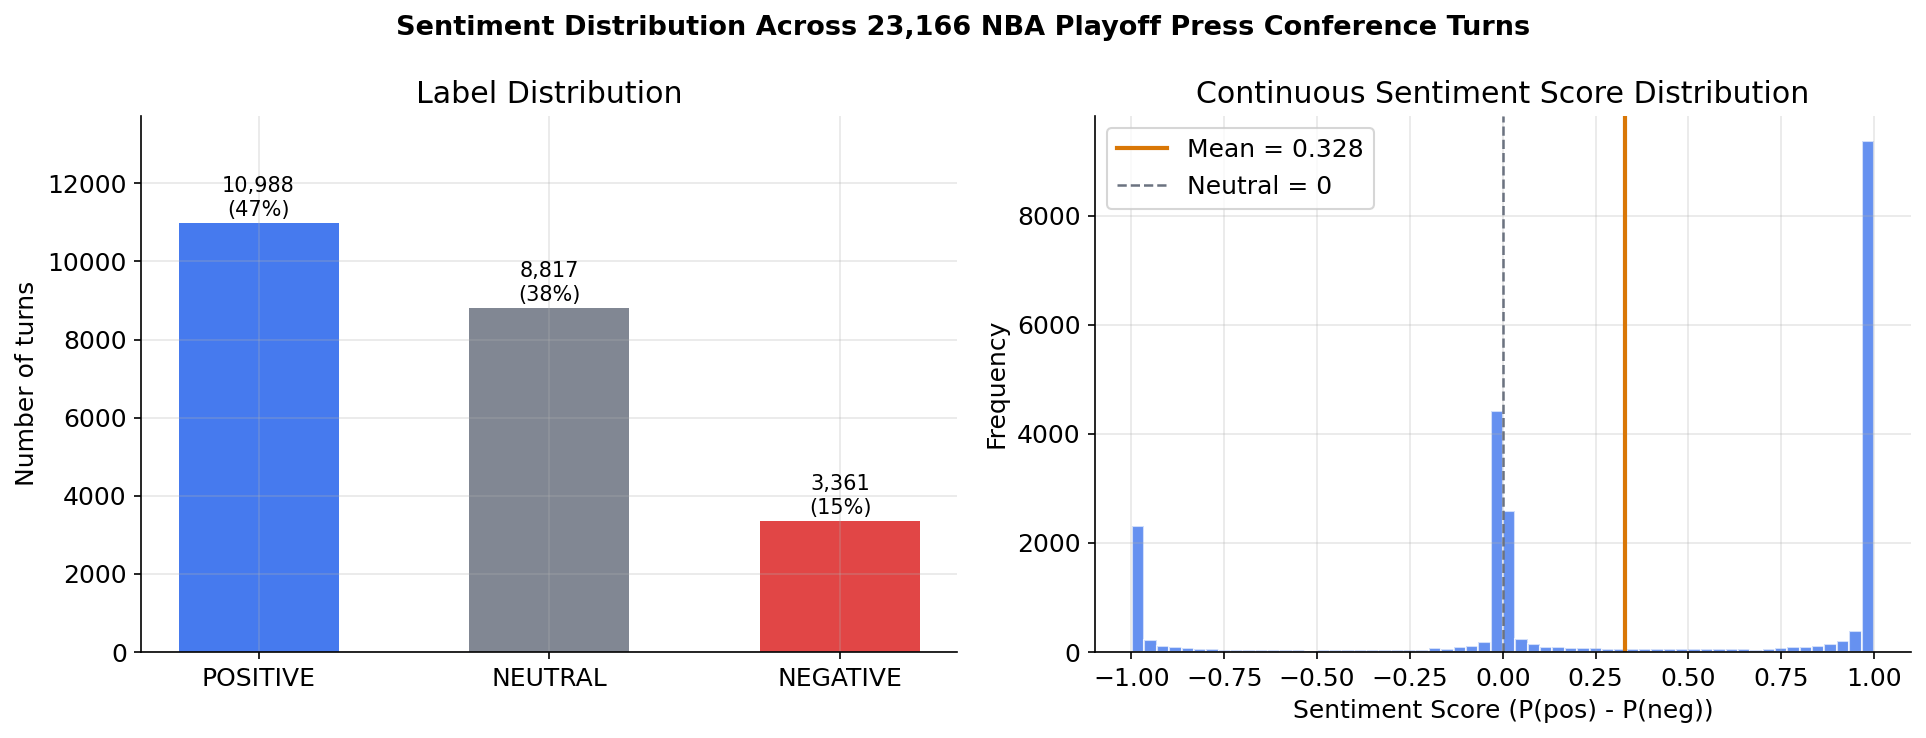

Saved 05_sentiment_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Sentiment Distribution Across 23,166 NBA Playoff Press Conference Turns",
             fontsize=13, fontweight="bold")

# Label breakdown
ax = axes[0]
counts = scores["sentiment_label"].value_counts()[["POSITIVE", "NEUTRAL", "NEGATIVE"]]
colors = [BLUE, GRAY, RED]
bars = ax.bar(counts.index, counts.values, color=colors, alpha=0.85, width=0.55)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 80,
            f"{count:,}\n({100*count/len(scores):.0f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of turns")
ax.set_title("Label Distribution")
ax.set_ylim(0, counts.max() * 1.25)

# Continuous score distribution
ax = axes[1]
ax.hist(scores["sentiment_numeric"], bins=60, color=BLUE, alpha=0.7, edgecolor="white")
ax.axvline(scores["sentiment_numeric"].mean(), color=YELLOW, linewidth=2,
           label=f"Mean = {scores['sentiment_numeric'].mean():.3f}")
ax.axvline(0, color=GRAY, linewidth=1.2, linestyle="--", label="Neutral = 0")
ax.set_xlabel("Sentiment Score (P(pos) - P(neg))")
ax.set_ylabel("Frequency")
ax.set_title("Continuous Sentiment Score Distribution")
ax.legend()

plt.tight_layout()
plt.savefig("05_sentiment_distribution.png", bbox_inches="tight")
plt.show()
print("Saved 05_sentiment_distribution.png")

## Figure 2: Model Performance Comparison

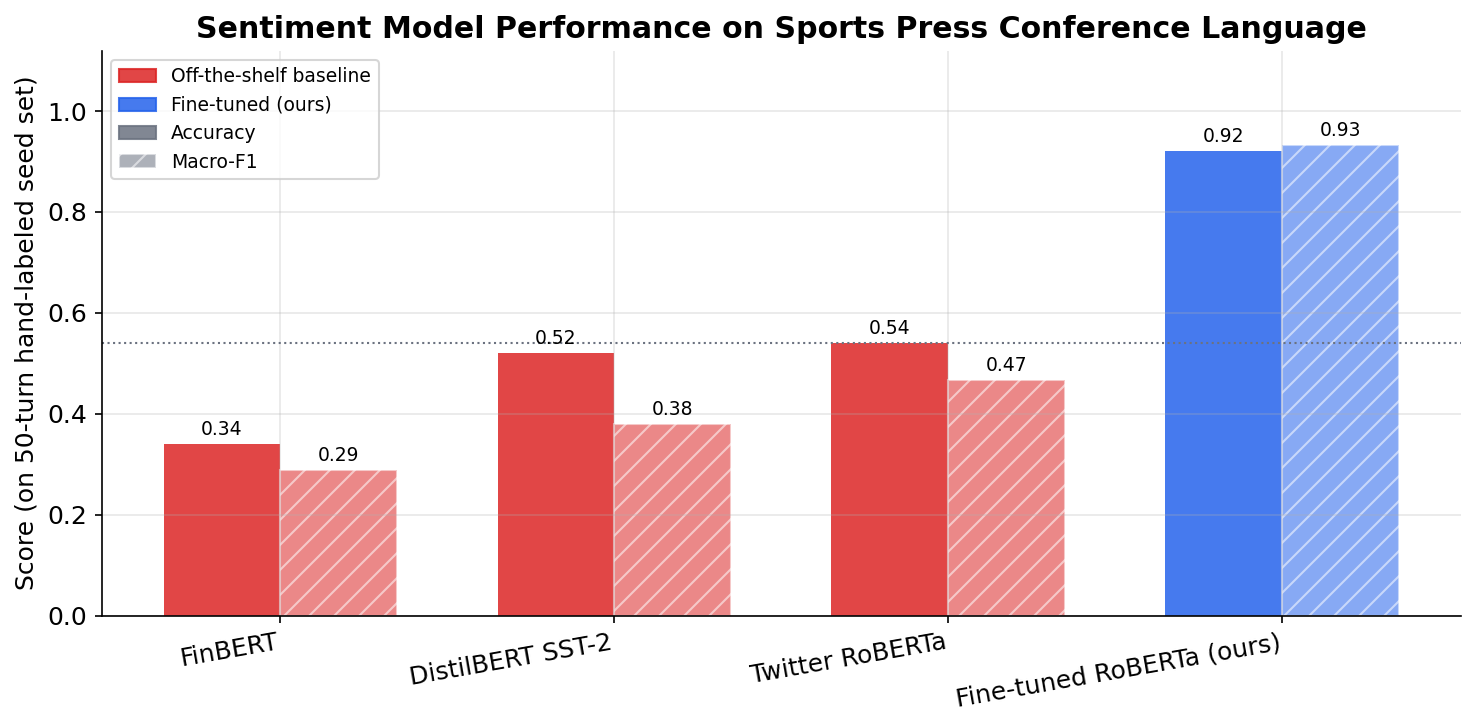

Saved 05_model_comparison.png


In [4]:
# Model comparison data from Phase 3 evaluation
model_data = pd.DataFrame([
    {"model": "FinBERT",                  "accuracy": 0.34, "macro_f1": 0.288, "type": "baseline"},
    {"model": "DistilBERT SST-2",         "accuracy": 0.52, "macro_f1": 0.380, "type": "baseline"},
    {"model": "Twitter RoBERTa",           "accuracy": 0.54, "macro_f1": 0.467, "type": "baseline"},
    {"model": "Fine-tuned RoBERTa (ours)", "accuracy": 0.92, "macro_f1": 0.932, "type": "finetuned"},
])

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(model_data))
w = 0.35

bar_colors = [RED if t == "baseline" else BLUE for t in model_data["type"]]
bars1 = ax.bar(x - w/2, model_data["accuracy"], w, label="Accuracy",
               color=bar_colors, alpha=0.85)
bars2 = ax.bar(x + w/2, model_data["macro_f1"],  w, label="Macro-F1",
               color=bar_colors, alpha=0.55, hatch="//", edgecolor="white")

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
            f"{h:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_data["model"], rotation=10, ha="right")
ax.set_ylabel("Score (on 50-turn hand-labeled seed set)")
ax.set_title("Sentiment Model Performance on Sports Press Conference Language",
             fontweight="bold")
ax.set_ylim(0, 1.12)
ax.axhline(0.54, color=GRAY, linewidth=1.0, linestyle=":", label="Best baseline (54%)")

baseline_patch  = mpatches.Patch(color=RED,  alpha=0.85, label="Off-the-shelf baseline")
finetuned_patch = mpatches.Patch(color=BLUE, alpha=0.85, label="Fine-tuned (ours)")
acc_patch  = mpatches.Patch(color=GRAY, alpha=0.85, label="Accuracy")
f1_patch   = mpatches.Patch(color=GRAY, alpha=0.55, hatch="//", label="Macro-F1", ec="white")
ax.legend(handles=[baseline_patch, finetuned_patch, acc_patch, f1_patch], fontsize=9)

plt.tight_layout()
plt.savefig("05_model_comparison.png", bbox_inches="tight")
plt.show()
print("Saved 05_model_comparison.png")

## Figure 3: Core Research Finding - Sentiment vs Point Differential

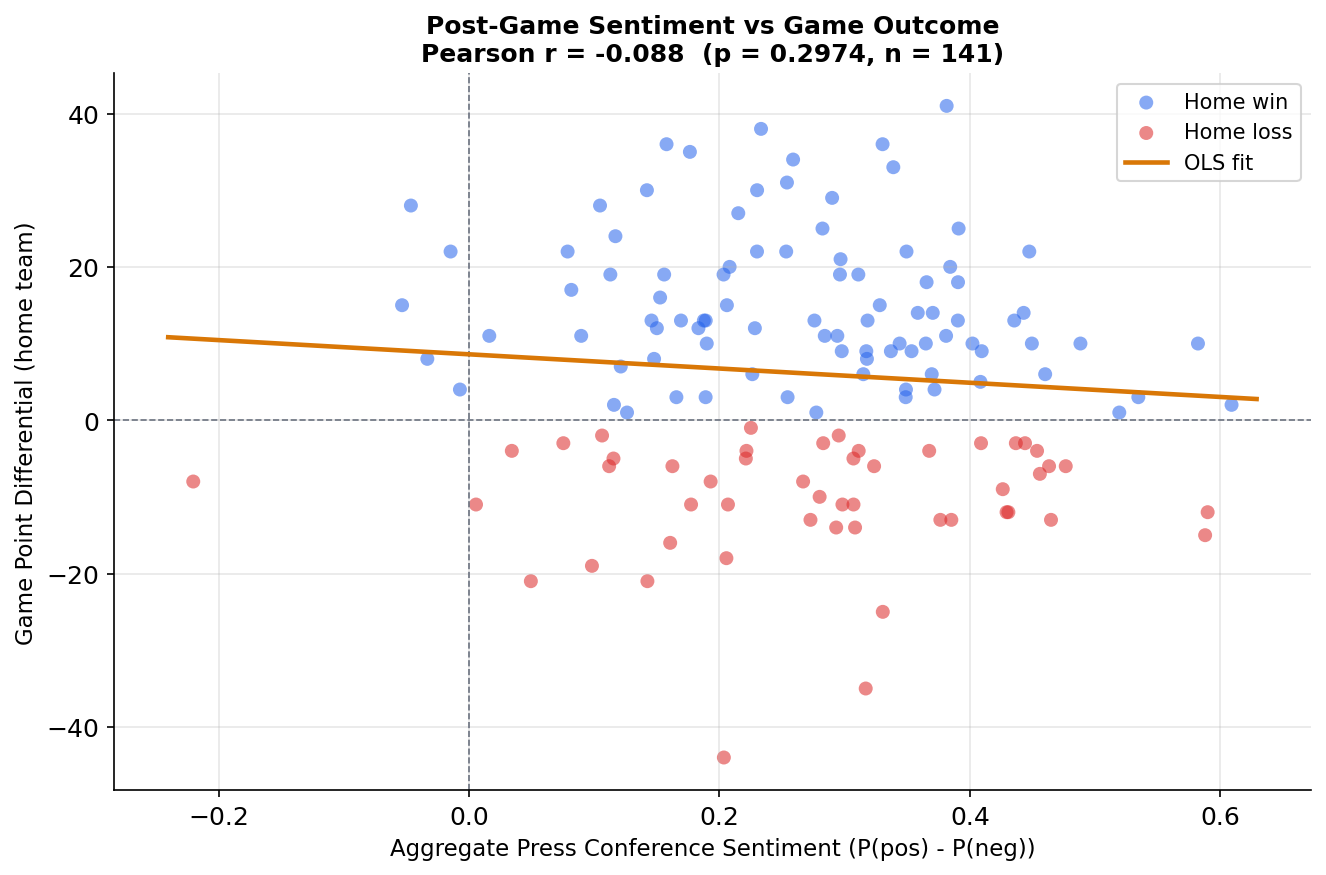

Saved 05_core_finding.png


In [5]:
mask = game_agg[["mean_sentiment", "point_diff"]].notna().all(axis=1)
x = game_agg.loc[mask, "mean_sentiment"]
y = game_agg.loc[mask, "point_diff"]
r, p = stats.pearsonr(x, y)

fig, ax = plt.subplots(figsize=(9, 6))

# Color by win/loss
wins   = game_agg.loc[mask & (game_agg["home_win"] == 1)]
losses = game_agg.loc[mask & (game_agg["home_win"] == 0)]

ax.scatter(wins["mean_sentiment"],   wins["point_diff"],
           color=BLUE, alpha=0.55, s=45, label="Home win",  edgecolors="none")
ax.scatter(losses["mean_sentiment"], losses["point_diff"],
           color=RED,  alpha=0.55, s=45, label="Home loss", edgecolors="none")

# Regression line
m, b = np.polyfit(x, y, 1)
xline = np.linspace(x.min() - 0.02, x.max() + 0.02, 100)
ax.plot(xline, m * xline + b, color=YELLOW, linewidth=2.2, zorder=5, label=f"OLS fit")

ax.axhline(0, color=GRAY, linewidth=0.8, linestyle="--")
ax.axvline(0, color=GRAY, linewidth=0.8, linestyle="--")

ax.set_xlabel("Aggregate Press Conference Sentiment (P(pos) - P(neg))", fontsize=11)
ax.set_ylabel("Game Point Differential (home team)", fontsize=11)
ax.set_title(
    f"Post-Game Sentiment vs Game Outcome\n"
    f"Pearson r = {r:+.3f}  (p = {p:.4f}, n = {mask.sum()})",
    fontweight="bold", fontsize=12
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("05_core_finding.png", bbox_inches="tight")
plt.show()
print("Saved 05_core_finding.png")

## Figure 4: Series Trajectory - Combined Panel

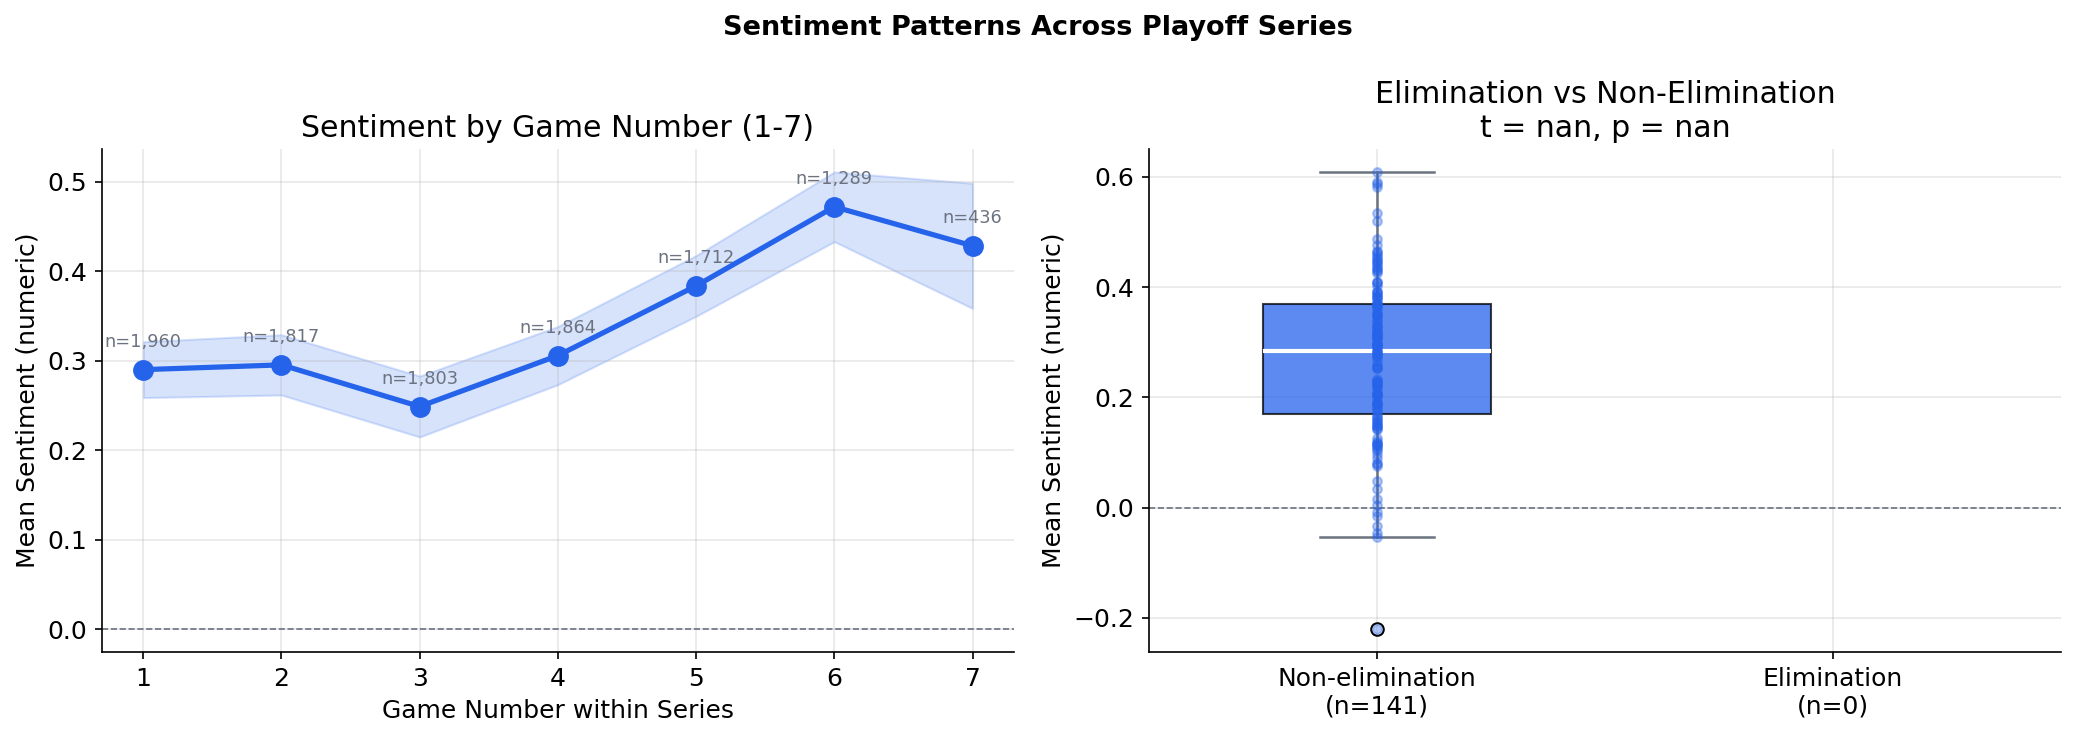

Saved 05_series_patterns.png


In [6]:
traj = (
    joined.groupby("game_num")["sentiment_numeric"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "mean_sentiment", "std": "std_sentiment", "count": "n_turns"})
    .reset_index()
)

elim_means   = game_agg[game_agg["is_elimination_game"] == 1]["mean_sentiment"]
normal_means = game_agg[game_agg["is_elimination_game"] == 0]["mean_sentiment"]
t_stat, p_val = stats.ttest_ind(elim_means, normal_means)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sentiment Patterns Across Playoff Series", fontsize=13, fontweight="bold")

# Left: trajectory
ax = axes[0]
sem = traj["std_sentiment"] / np.sqrt(traj["n_turns"])
ax.plot(traj["game_num"], traj["mean_sentiment"],
        marker="o", linewidth=2.5, color=BLUE, markersize=9, zorder=5)
ax.fill_between(traj["game_num"],
                traj["mean_sentiment"] - 1.96 * sem,
                traj["mean_sentiment"] + 1.96 * sem,
                alpha=0.18, color=BLUE)
ax.axhline(0, color=GRAY, linewidth=0.8, linestyle="--")
ax.set_xticks(traj["game_num"])
ax.set_xlabel("Game Number within Series")
ax.set_ylabel("Mean Sentiment (numeric)")
ax.set_title("Sentiment by Game Number (1-7)")
for _, row in traj.iterrows():
    ax.annotate(f"n={int(row['n_turns']):,}", (row["game_num"], row["mean_sentiment"]),
                textcoords="offset points", xytext=(0, 11),
                ha="center", fontsize=8.5, color=GRAY)

# Right: elimination vs non-elimination box plot
ax = axes[1]
data_to_plot = [normal_means.values, elim_means.values]
bp = ax.boxplot(data_to_plot, patch_artist=True, widths=0.5,
                medianprops={"color": "white", "linewidth": 2})
for patch, color in zip(bp["boxes"], [BLUE, RED]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for whisker in bp["whiskers"]:
    whisker.set(color=GRAY, linewidth=1.2)
for cap in bp["caps"]:
    cap.set(color=GRAY, linewidth=1.2)

ax.scatter([1] * len(normal_means), normal_means, alpha=0.35, s=18, color=BLUE, zorder=3)
ax.scatter([2] * len(elim_means),   elim_means,   alpha=0.35, s=18, color=RED,  zorder=3)
ax.set_xticks([1, 2])
ax.set_xticklabels([f"Non-elimination\n(n={len(normal_means)})",
                    f"Elimination\n(n={len(elim_means)})"])
ax.set_ylabel("Mean Sentiment (numeric)")
sig_str = f"p = {p_val:.4f}" + (" *" if p_val < 0.05 else "")
ax.set_title(f"Elimination vs Non-Elimination\nt = {t_stat:.3f}, {sig_str}")
ax.axhline(0, color=GRAY, linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.savefig("05_series_patterns.png", bbox_inches="tight")
plt.show()
print("Saved 05_series_patterns.png")

## Figure 5: Top Speakers by Sentiment Polarity

In [7]:
# Aggregate by speaker - only speakers with >= 50 turns for reliability
speaker_agg = (
    joined.groupby("speaker")
    .agg(
        mean_sentiment=("sentiment_numeric", "mean"),
        pct_positive=("sentiment_label", lambda x: (x == "POSITIVE").mean()),
        n_turns=("sentiment_numeric", "count"),
    )
    .reset_index()
    .query("n_turns >= 50")
    .sort_values("mean_sentiment", ascending=False)
)

print(f"Speakers with >= 50 turns: {len(speaker_agg)}")
print(speaker_agg.head(10).to_string(index=False))

Speakers with >= 50 turns: 56
              speaker  mean_sentiment  pct_positive  n_turns
         JORDAN POOLE        0.758016      0.763636       55
          STEPH CURRY        0.720933      0.776786      112
        DEANDRE AYTON        0.619895      0.681818       66
       ANDREW WIGGINS        0.610642      0.630769       65
        KLAY THOMPSON        0.567442      0.724138      174
GIANNIS ANTETOKOUNMPO        0.553041      0.650000      120
     MIKE BUDENHOLZER        0.537372      0.607362      326
         KYRIE IRVING        0.530560      0.684783       92
         MARCUS SMART        0.515681      0.685185       54
         JOHN COLLINS        0.513263      0.650000       60


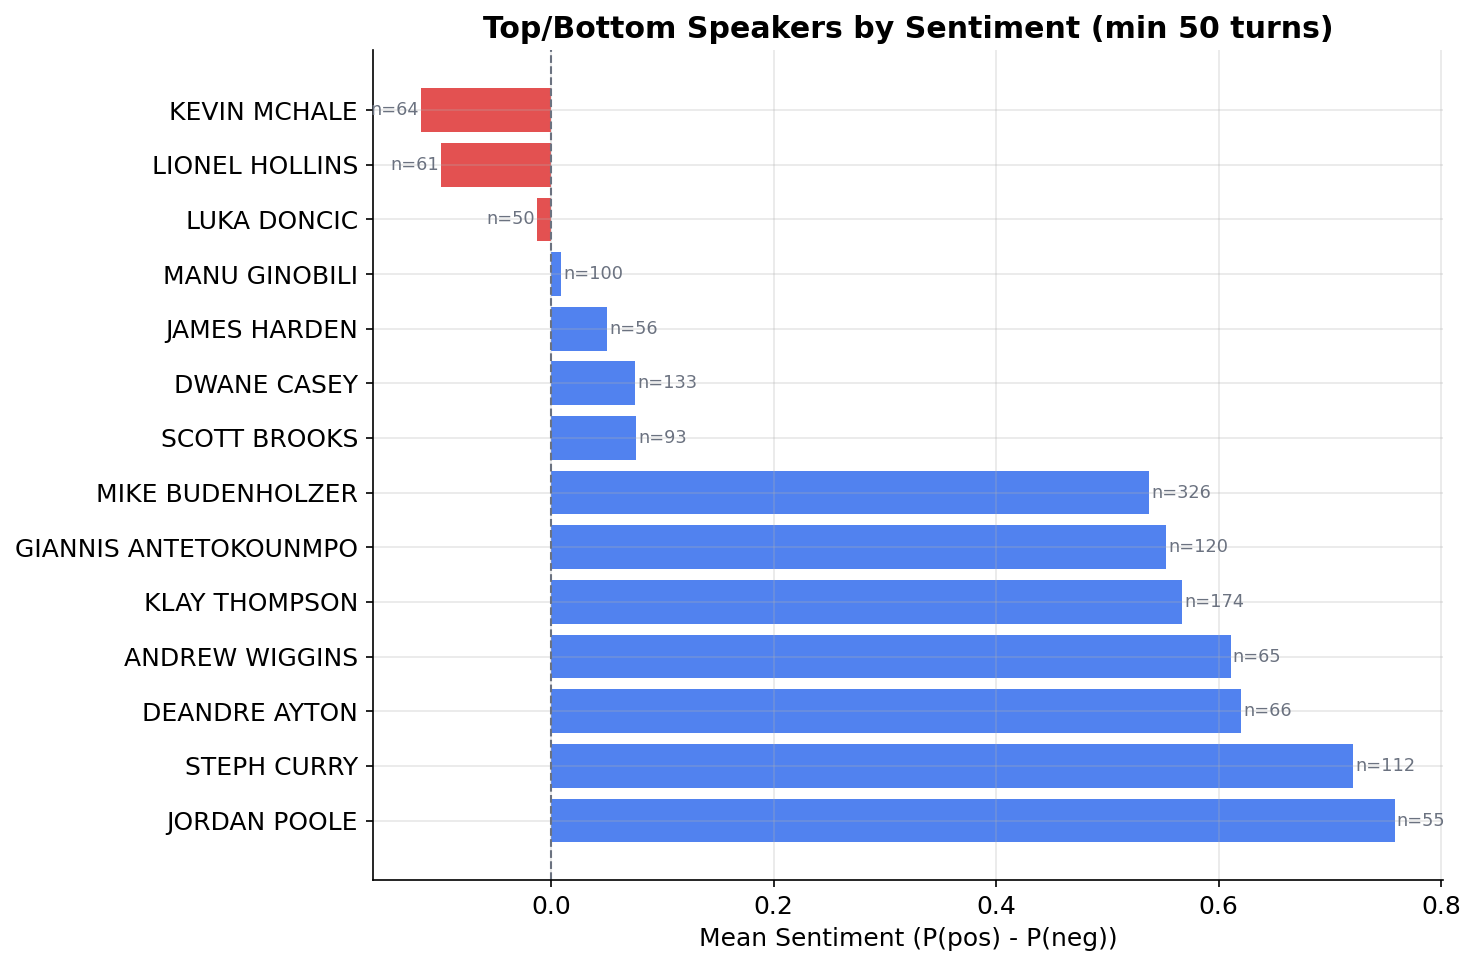

Saved 05_speaker_sentiment.png


In [8]:
top_n = min(15, len(speaker_agg))
if top_n > 0:
    # Show top 8 most positive and bottom 8 most negative (or fewer if not enough)
    n_each = min(8, top_n // 2)
    display_df = pd.concat([
        speaker_agg.head(n_each),
        speaker_agg.tail(n_each),
    ]).drop_duplicates(subset="speaker")

    fig, ax = plt.subplots(figsize=(10, max(5, len(display_df) * 0.4 + 1)))
    colors = [BLUE if v >= 0 else RED for v in display_df["mean_sentiment"]]
    bars = ax.barh(display_df["speaker"], display_df["mean_sentiment"],
                   color=colors, alpha=0.8)
    ax.axvline(0, color=GRAY, linewidth=1.0, linestyle="--")
    for bar, row in zip(bars, display_df.itertuples()):
        x_pos = bar.get_width() + 0.002 * (1 if bar.get_width() >= 0 else -1)
        ha = "left" if bar.get_width() >= 0 else "right"
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                f"n={row.n_turns}", va="center", ha=ha, fontsize=8.5, color=GRAY)
    ax.set_xlabel("Mean Sentiment (P(pos) - P(neg))")
    ax.set_title(f"Top/Bottom Speakers by Sentiment (min 50 turns)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("05_speaker_sentiment.png", bbox_inches="tight")
    plt.show()
    print("Saved 05_speaker_sentiment.png")
else:
    print("Not enough speakers with >= 50 turns to plot.")

## Summary Table: All Correlation Results

In [9]:
from src.analysis.correlations import pearson_analysis, build_game_aggregates

pearson = pearson_analysis(game_agg)

summary_rows = []
for label, res in pearson.items():
    summary_rows.append({
        "Analysis": label,
        "Pearson r": f"{res['r']:+.3f}",
        "p-value": f"{res['p']:.4f}",
        "n": res["n"],
        "Significant (a=0.05)": "Yes" if res["p"] < 0.05 else "No",
    })

t_stat, p_val = stats.ttest_ind(
    game_agg[game_agg["is_elimination_game"] == 1]["mean_sentiment"],
    game_agg[game_agg["is_elimination_game"] == 0]["mean_sentiment"]
)
summary_rows.append({
    "Analysis": "Elimination game sentiment (t-test)",
    "Pearson r": f"t={t_stat:.3f}",
    "p-value": f"{p_val:.4f}",
    "n": len(game_agg),
    "Significant (a=0.05)": "Yes" if p_val < 0.05 else "No",
})

summary_df = pd.DataFrame(summary_rows)
print("\nFull Results Summary:\n")
print(summary_df.to_string(index=False))


Full Results Summary:

                           Analysis Pearson r p-value   n Significant (a=0.05)
sentiment vs point_diff (same game)    -0.088  0.2974 141                   No
  sentiment vs next-game point_diff    -0.109  0.1962 141                   No
         pct_positive vs point_diff    -0.066  0.4340 141                   No
         pct_negative vs point_diff    +0.053  0.5332 141                   No
Elimination game sentiment (t-test)     t=nan     nan 141                   No
